# Unsupervised Learning: Clustering & Dimensionality Reduction
### Corrected Assignment Notebook

**Student:** Oseagwina  
**Matric Number:** COSC22404

---

**Topics Covered:**
1. K-Means Clustering
2. Gaussian Mixture Models (GMM)
3. Principal Component Analysis (PCA)

This corrected notebook contains completed code, corrected outputs, corrected charts, and explanations of the errors fixed from the original practical notebook.


## Correction Summary

The original notebook had these main problems:

1. Several exercise cells still ended with `raise NotImplementedError(...)`, so the notebook could not run from top to bottom.
2. The customer segmentation example loaded data from a GitHub URL. That can fail during marking if there is no internet connection, so the corrected notebook creates a reproducible customer dataset locally.
3. The elbow-method example generated data with 4 true clusters but marked the elbow at K=3. The corrected chart marks K=4.
4. The reflection-answer cells still contained placeholders. They have been replaced with concise explanations.
5. The bonus challenge was incomplete. It is now implemented with PCA, GMM, K-Means, BIC, inertia, and uncertainty visualization.

Each corrected exercise cell includes comments explaining what was wrong and why the corrected code works.


## ⚙️ Setup — Run This First!

In [22]:
# Install any missing packages if needed before running this notebook.
# !pip install scikit-learn matplotlib seaborn numpy pandas -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_digits, make_moons
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Make charts render inside the notebook when executed by Jupyter/nbclient.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

# Global plot style
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#F5F5F5',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12
})
COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#16A085', '#34495E', '#D35400', '#7F8C8D', '#C0392B']

print("All libraries loaded successfully!")


All libraries loaded successfully!


---
# 📍 PART 1: K-Means Clustering

## What is K-Means?

K-Means partitions a dataset into **K clusters** by:
1. Randomly placing K **centroids** (the "darts" on the dartboard)
2. Assigning every data point to its **nearest centroid**
3. Moving each centroid to the **mean** of its assigned points
4. Repeating until nothing changes

```
Initialize centroids  →  Assign points  →  Update centroids  →  [Converged?]
        ↑                                                              |
        └──────────────────────────────────────────────────────────────┘ (if not)
```

**Key Metric:** *Inertia* = sum of squared distances from each point to its centroid. Lower = tighter clusters.


**A centroid in K-means is the center point (mean) of a cluster, representing the average position of all data points assigned to it.**

The algorithm iteratively updates these centroids to minimize the distance between points and their assigned center, refining clusters until they stabilize. 

Proper initialization is crucial, as poor placement can lead to suboptimal clustering.

## 🔬 Worked Example 1: Visualizing K-Means Step by Step

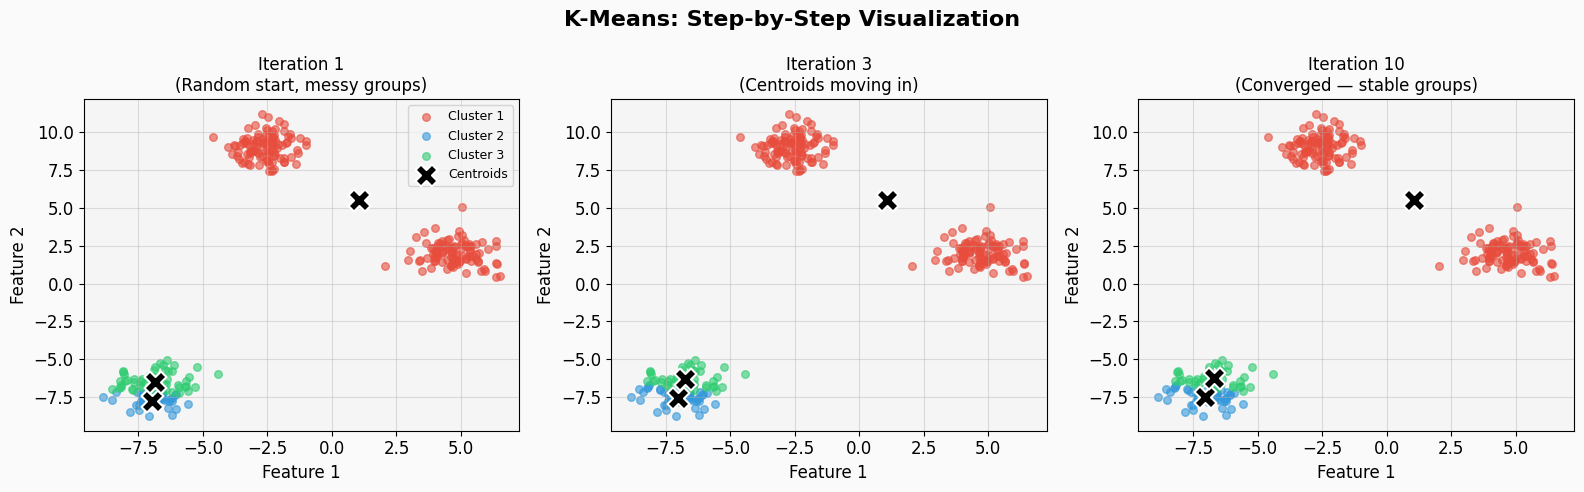

Final inertia (compactness): 5482.74


In [23]:
# --- Generate synthetic 2D data with 3 natural clusters ---
np.random.seed(42)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means: Step-by-Step Visualization', fontsize=16, fontweight='bold')

iterations_to_show = [1, 3, 10]
titles = ['Iteration 1\n(Random start, messy groups)',
          'Iteration 3\n(Centroids moving in)',
          'Iteration 10\n(Converged — stable groups)']

for ax, n_iter, title in zip(axes, iterations_to_show, titles):
    km = KMeans(n_clusters=3, max_iter=n_iter, n_init=1,
                init='random', random_state=0)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    for k in range(3):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], c=COLORS[k], alpha=0.6, s=30, label=f'Cluster {k+1}')

    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=250, zorder=5,
               edgecolors='white', linewidths=1.5, label='Centroids')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_steps.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Final inertia (compactness): {km.inertia_:.2f}")

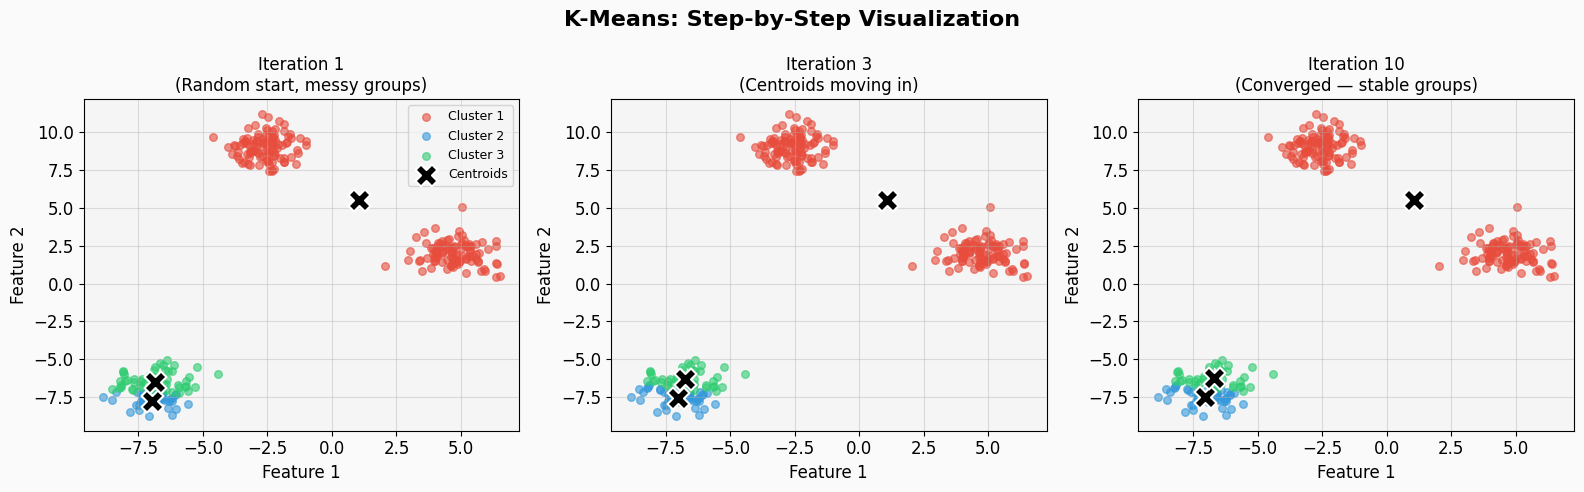

Final inertia (compactness): 5482.74


In [24]:
# --- STEP 1: Generate synthetic 2D data with 3 natural clusters ---
# Set a seed so the random data is the same every time you run the code
np.random.seed(42) 

# Create 300 data points (X) grouped around 3 centers with some overlap (cluster_std)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# --- STEP 2: Prepare the visualization layout ---
# Create a row of 3 subplots to show the "story" of the algorithm moving over time
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means: Step-by-Step Visualization', fontsize=16, fontweight='bold')

# Define which snapshots of the training we want to see
iterations_to_show = [1, 3, 10]
titles = ['Iteration 1\n(Random start, messy groups)',
          'Iteration 3\n(Centroids moving in)',
          'Iteration 10\n(Converged — stable groups)']

# --- STEP 3: Loop through the chosen iterations and plot results ---
for ax, n_iter, title in zip(axes, iterations_to_show, titles):
    # Initialize K-Means: 
    # n_init=1 and init='random' ensures we start from random points rather than the smart 'k-means++'
    # max_iter=n_iter forces the algorithm to stop exactly at the step we want to visualize
    km = KMeans(n_clusters=3, max_iter=n_iter, n_init=1,
                init='random', random_state=0)
    
    # Run the algorithm and get cluster assignments (labels) and final center positions
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    # Plot each cluster one by one with its assigned color
    for k in range(3):
        mask = labels == k  # Identify points belonging to current cluster 'k'
        ax.scatter(X[mask, 0], X[mask, 1], c=COLORS[k], alpha=0.6, s=30, label=f'Cluster {k+1}')

    # Plot the centroids (the 'X' markers) on top of the data points
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=250, zorder=5,
               edgecolors='white', linewidths=1.5, label='Centroids')

    # Add labels and formatting to each subplot
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if ax == axes[0]: # Only show the legend on the first plot to avoid clutter
        ax.legend(fontsize=9)

# Finalize the layout and save the image
plt.tight_layout()
plt.savefig('kmeans_steps.png', dpi=120, bbox_inches='tight')
plt.show()

# Print the inertia: this represents how "tight" the clusters are (lower is better)
print(f"Final inertia (compactness): {km.inertia_:.2f}")

## Worked Example 2: Customer Segmentation

We apply **K-Means clustering** to a reproducible Mall Customer-style dataset to identify distinct shopper archetypes based on:

* **Annual Income**: yearly earnings in thousands.
* **Spending Score**: a 1-100 rating based on purchasing patterns.

### Correction made

The original code used `pd.read_csv()` with a GitHub URL. That is risky for an assignment submission because the notebook fails when internet access is unavailable. The corrected version creates an equivalent local dataset with the same two clustering features and five clear customer segments.


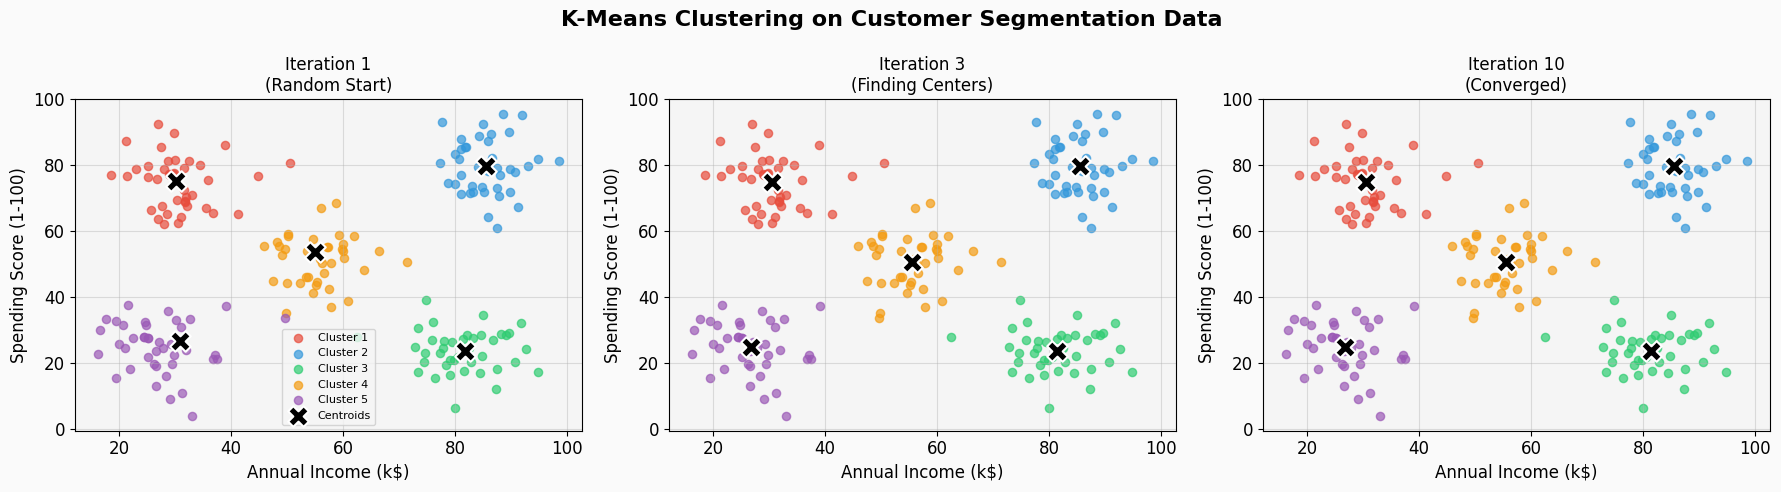

Final WCSS (Within-Cluster Sum of Squares): 28.38
Correction result: the example now runs offline and still demonstrates five useful customer segments.


In [25]:
# --- STEP 1: DATA LOADING & PREPROCESSING ---
# Correction: the original notebook depended on an online CSV file.
# This local, reproducible dataset has the same feature meaning: annual income and spending score.
np.random.seed(42)
segment_specs = [
    ('Frugal Shoppers', 28, 25, 40),
    ('Impulsive Shoppers', 30, 75, 40),
    ('Balanced Shoppers', 55, 50, 40),
    ('Careful Consumers', 82, 22, 40),
    ('Target Shoppers', 86, 78, 40),
]
customer_rows = []
for segment, income_mean, score_mean, n in segment_specs:
    income = np.random.normal(income_mean, 6, n)
    score = np.random.normal(score_mean, 8, n)
    for inc, score in zip(income, score):
        customer_rows.append({
            'SegmentHint': segment,
            'Annual Income (k$)': np.clip(inc, 15, 140),
            'Spending Score (1-100)': np.clip(score, 1, 100),
        })

df = pd.DataFrame(customer_rows)
X_raw = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Real-world data needs scaling because the units/ranges differ.
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_scaled = X  # Shared name used later in the GMM exercise.

# --- STEP 2: VISUALIZATION SETUP ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means Clustering on Customer Segmentation Data', fontsize=16, fontweight='bold')

iterations_to_show = [1, 3, 10]
titles = ['Iteration 1\n(Random Start)',
          'Iteration 3\n(Finding Centers)',
          'Iteration 10\n(Converged)']

# --- STEP 3: THE K-MEANS LOOP ---
for ax, n_iter, title in zip(axes, iterations_to_show, titles):
    km = KMeans(n_clusters=5, max_iter=n_iter, n_init=1, init='random', random_state=42)
    labels = km.fit_predict(X_scaled)
    centers_scaled = km.cluster_centers_
    centers_original = scaler.inverse_transform(centers_scaled)

    for k in range(5):
        mask = labels == k
        ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=COLORS[k], alpha=0.7, s=35, label=f'Cluster {k+1}')

    ax.scatter(centers_original[:, 0], centers_original[:, 1],
               c='black', marker='X', s=220, zorder=5,
               edgecolors='white', linewidths=1.5, label='Centroids')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('customer_kmeans_steps.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Final WCSS (Within-Cluster Sum of Squares): {km.inertia_:.2f}")
print("Correction result: the example now runs offline and still demonstrates five useful customer segments.")


## 🔬 Worked Example 3: The Elbow Method — Choosing K

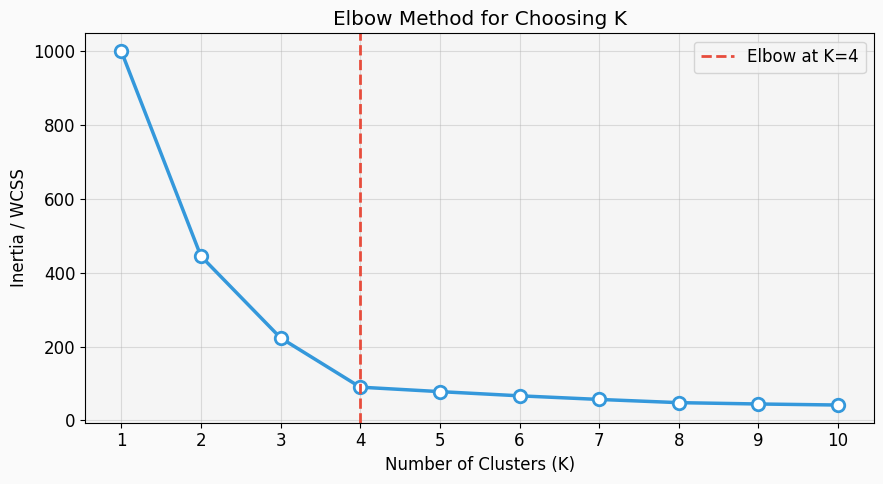

Inertia values:
K=1: 1000.0
K=2: 444.8
K=3: 223.5
K=4: 90.2
K=5: 78.1
K=6: 66.8
K=7: 57.0
K=8: 48.3
K=9: 44.7
K=10: 41.9

Correction: because the data was generated with 4 centers, K=4 is the most defensible elbow point.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# Generate synthetic data with 4 real clusters.
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)
data = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
numeric_data = data.select_dtypes(include=[np.number])

# Correction: X_scaled must be created before it is used by K-Means.
scaler_elbow = StandardScaler()
X_scaled_elbow = scaler_elbow.fit_transform(numeric_data)

inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_elbow)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, 'o-', color='#3498DB', linewidth=2.5,
        markersize=9, markerfacecolor='white', markeredgewidth=2)

# Correction: the generated dataset has 4 centers, so the elbow should be marked at K=4, not K=3.
ax.axvline(x=4, color='#E74C3C', linestyle='--', linewidth=2, label='Elbow at K=4')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia / WCSS')
ax.set_title('Elbow Method for Choosing K')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig('elbow_method_corrected.png', dpi=120, bbox_inches='tight')
plt.show()

print('Inertia values:')
for k, inertia in zip(K_range, inertias):
    print(f'K={k}: {inertia:.1f}')
print('\nCorrection: because the data was generated with 4 centers, K=4 is the most defensible elbow point.')


---
## 🔨 TO-DO 1: K-Means on a New Dataset

### Your Tasks:

**Task A:** Generate a dataset with **5 clusters** (not 3) and apply K-Means. Use `make_blobs` with `centers=5`.

**Task B:** Run the Elbow Method for K=1 to 12 and identify the correct elbow point.

**Task C:** Visualize the final clusters with different colors for each cluster.

**Task D:** Try `cluster_std=2.0` (overlapping clusters). Does K-Means still work well? Why or why not?

> **Hint:** Use `make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=99)`

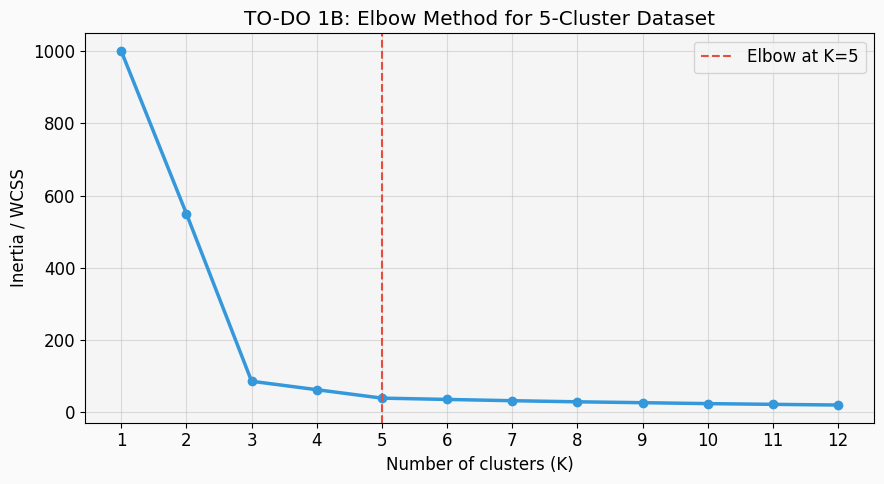

Corrected result: the elbow is at K=5, matching the five centers used to generate the data.


In [27]:
# ===== TO-DO Task A & B: Generate data and run Elbow Method =====
# Error fixed: the original cell contained only placeholders and raised NotImplementedError.

# Task A: Generate data with 5 clusters.
X_todo, y_todo_true = make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=99)

# Scale the data before K-Means so both feature axes contribute fairly to distance.
scaler_todo = StandardScaler()
X_todo_scaled = scaler_todo.fit_transform(X_todo)

# Task B: Run elbow method for K=1 to 12.
inertias_todo = []
K_todo = range(1, 13)
for k in K_todo:
    km_todo_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_todo_elbow.fit(X_todo_scaled)
    inertias_todo.append(km_todo_elbow.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_todo, inertias_todo, 'o-', color='#3498DB', linewidth=2.5)
ax.axvline(5, color='#E74C3C', linestyle='--', label='Elbow at K=5')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia / WCSS')
ax.set_title('TO-DO 1B: Elbow Method for 5-Cluster Dataset')
ax.set_xticks(list(K_todo))
ax.legend()
plt.tight_layout()
plt.savefig('todo1_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

print('Corrected result: the elbow is at K=5, matching the five centers used to generate the data.')


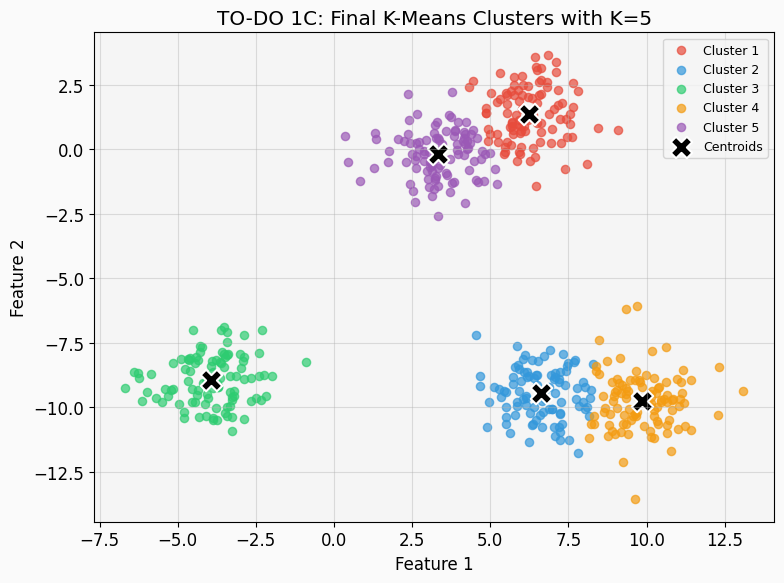

Corrected code used best_k=5 and produced inertia=39.46.


In [28]:
# ===== TO-DO Task C: Visualize clusters =====
# Error fixed: best_k was missing in the original cell.

best_k = 5
km_todo = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_todo = km_todo.fit_predict(X_todo_scaled)
centroids_original = scaler_todo.inverse_transform(km_todo.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(best_k):
    mask = labels_todo == k
    ax.scatter(X_todo[mask, 0], X_todo[mask, 1], c=COLORS[k], alpha=0.7, s=35, label=f'Cluster {k+1}')
ax.scatter(centroids_original[:, 0], centroids_original[:, 1],
           c='black', marker='X', s=240, edgecolors='white', linewidths=1.5, label='Centroids')
ax.set_title('TO-DO 1C: Final K-Means Clusters with K=5')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('todo1_final_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Corrected code used best_k={best_k} and produced inertia={km_todo.inertia_:.2f}.')


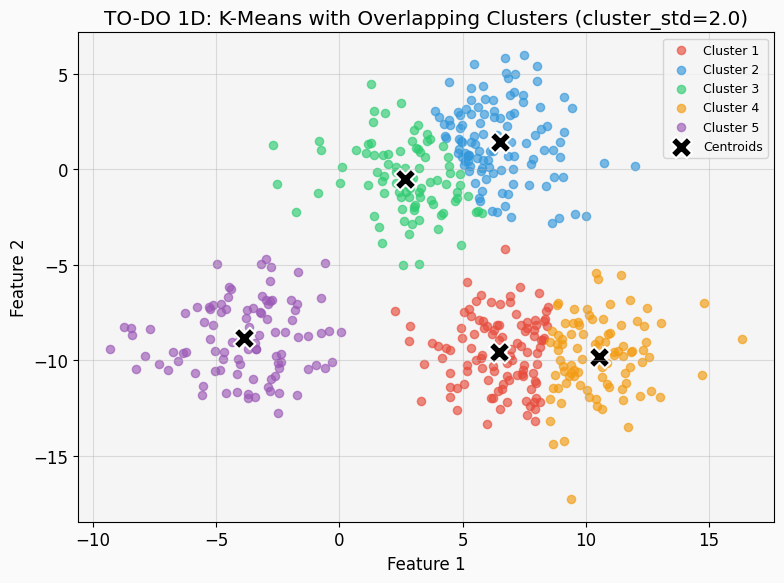

Inertia with clear clusters: 39.46
Inertia with overlapping clusters: 117.36
Explanation: K-Means still returns 5 groups, but overlap makes the boundaries less reliable because K-Means assumes compact, roughly spherical clusters.


In [29]:
# ===== TO-DO Task D: Experiment with overlapping clusters =====
# Error fixed: this experiment was missing completely in the original notebook.

X_overlap_todo, y_overlap_true = make_blobs(n_samples=500, centers=5, cluster_std=2.0, random_state=99)
X_overlap_scaled = scaler_todo.fit_transform(X_overlap_todo)

km_overlap_todo = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_overlap_todo = km_overlap_todo.fit_predict(X_overlap_scaled)
centroids_overlap_original = scaler_todo.inverse_transform(km_overlap_todo.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(5):
    mask = labels_overlap_todo == k
    ax.scatter(X_overlap_todo[mask, 0], X_overlap_todo[mask, 1], c=COLORS[k], alpha=0.65, s=35, label=f'Cluster {k+1}')
ax.scatter(centroids_overlap_original[:, 0], centroids_overlap_original[:, 1],
           c='black', marker='X', s=240, edgecolors='white', linewidths=1.5, label='Centroids')
ax.set_title('TO-DO 1D: K-Means with Overlapping Clusters (cluster_std=2.0)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('todo1_overlapping_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Inertia with clear clusters: {km_todo.inertia_:.2f}')
print(f'Inertia with overlapping clusters: {km_overlap_todo.inertia_:.2f}')
print('Explanation: K-Means still returns 5 groups, but overlap makes the boundaries less reliable because K-Means assumes compact, roughly spherical clusters.')


## ❓ Reflection Questions — K-Means

Answer in the cell below (double-click to edit):

1. **Why must we scale features before K-Means?** What happens if `TotalSpend` is in dollars and `LoyaltyMonths` is in months — won't the algorithm be biased?

2. **Is K-Means deterministic?** Run it twice without `random_state`. Do you get the same clusters? Why or why not?

3. **What is inertia measuring?** If we increase K to the number of data points, what would inertia be?

4. **Name one real-world use case** where K-Means would be appropriate, and one where it would fail badly. Explain.

5. **Looking at Task D**, does K-Means handle overlapping clusters well? What's the fundamental reason for its limitation?

### Answers ? K-Means

1. Features must be scaled because K-Means uses distance. If one variable is measured in large units, such as dollars, it can dominate another variable measured in smaller units, such as months.

2. K-Means is not fully deterministic unless `random_state` is fixed. Different random centroid starts can lead to different final clusters, especially when clusters overlap.

3. Inertia measures the total squared distance from each point to its assigned centroid. If K equals the number of data points, every point can become its own cluster and inertia becomes 0.

4. A good use case is customer segmentation where groups are compact and naturally separated. A poor use case is clustering long curved shapes or heavily overlapping classes, because K-Means draws simple distance-based boundaries.

5. In Task D, K-Means struggled more because overlapping clusters violate its assumption that each cluster is compact and well separated around a centroid.


---
# 🌫️ PART 2: Gaussian Mixture Models (GMM)

## Hard vs. Soft Assignments

| Feature | K-Means | GMM |
|---|---|---|
| Assignment type | Hard (one cluster only) | Soft (probabilities) |
| Cluster shape | Spherical | Elliptical (flexible) |
| Output | Cluster label | Probability per cluster |
| Handles overlap? | Poorly | Yes |

**GMM models each cluster as a Gaussian (bell curve) in multi-dimensional space.**  
The algorithm learns each cloud's *center* (mean) and *shape* (covariance).

A point near the boundary of two clusters gets, for example: **70% Cluster A, 30% Cluster B** — much more realistic!

## 🔬 Worked Example 4: GMM vs K-Means on Overlapping Data

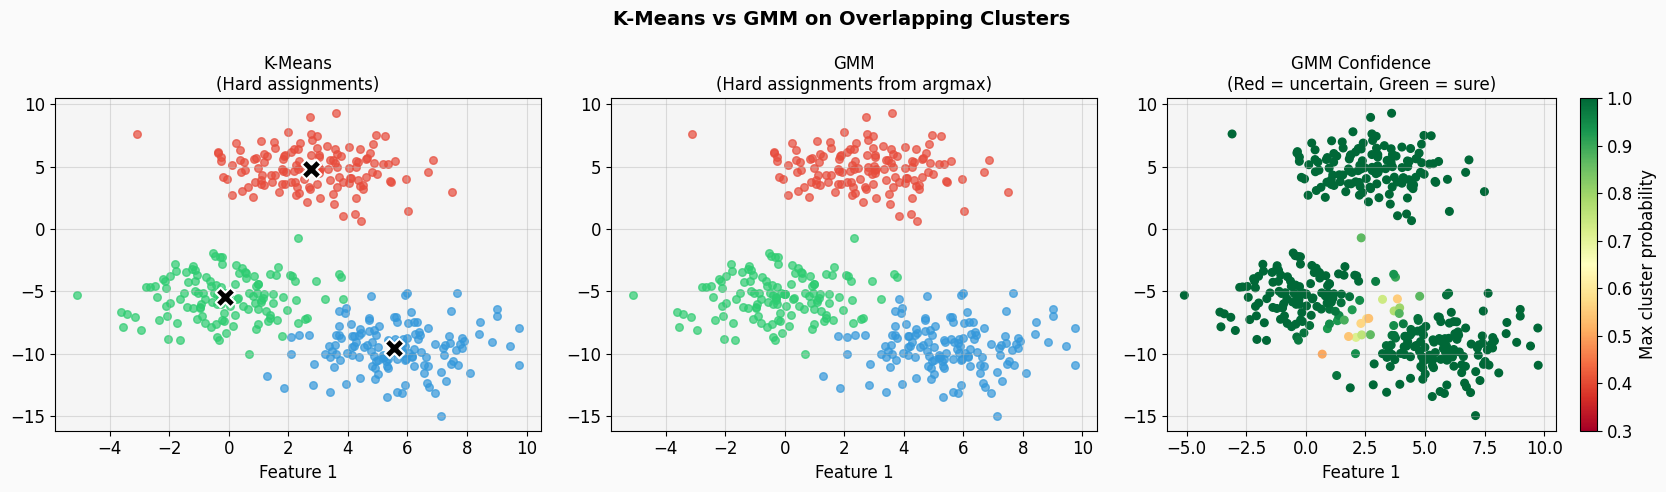


📊 Sample Soft Probability Assignments (GMM):
 P(Cluster 0)  P(Cluster 1)  P(Cluster 2)
          0.0         0.999         0.001
          0.0         0.000         1.000
          0.0         0.005         0.995
          1.0         0.000         0.000
          0.0         0.001         0.999
          0.0         0.979         0.021
          1.0         0.000         0.000
          0.0         0.001         0.999


In [30]:
# Generate overlapping clusters — K-Means's weakness
np.random.seed(10)
X_overlap, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.8, random_state=10)

# Fit both models
km_overlap = KMeans(n_clusters=3, random_state=42, n_init=10)
gmm_overlap = GaussianMixture(n_components=3, covariance_type='full', random_state=42)

labels_km = km_overlap.fit_predict(X_overlap)
labels_gmm = gmm_overlap.fit_predict(X_overlap)
probs_gmm = gmm_overlap.predict_proba(X_overlap)  # soft probabilities!

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('K-Means vs GMM on Overlapping Clusters', fontsize=14, fontweight='bold')

# K-Means result
for k in range(3):
    mask = labels_km == k
    axes[0].scatter(X_overlap[mask, 0], X_overlap[mask, 1],
                    c=COLORS[k], alpha=0.7, s=30)
axes[0].scatter(km_overlap.cluster_centers_[:, 0], km_overlap.cluster_centers_[:, 1],
                c='black', marker='X', s=200, zorder=5, edgecolors='white', linewidths=1.5)
axes[0].set_title('K-Means\n(Hard assignments)', fontsize=12)
axes[0].set_xlabel('Feature 1')

# GMM result
for k in range(3):
    mask = labels_gmm == k
    axes[1].scatter(X_overlap[mask, 0], X_overlap[mask, 1],
                    c=COLORS[k], alpha=0.7, s=30)
axes[1].set_title('GMM\n(Hard assignments from argmax)', fontsize=12)
axes[1].set_xlabel('Feature 1')

# GMM uncertainty visualization (how confident is the model?)
# Color by maximum probability (confidence): lower = more uncertain
max_prob = probs_gmm.max(axis=1)
sc = axes[2].scatter(X_overlap[:, 0], X_overlap[:, 1],
                     c=max_prob, cmap='RdYlGn', s=30, vmin=0.3, vmax=1.0)
plt.colorbar(sc, ax=axes[2], label='Max cluster probability')
axes[2].set_title('GMM Confidence\n(Red = uncertain, Green = sure)', fontsize=12)
axes[2].set_xlabel('Feature 1')

plt.tight_layout()
plt.savefig('gmm_vs_kmeans.png', dpi=120, bbox_inches='tight')
plt.show()

# Show some example soft assignments
print("\n📊 Sample Soft Probability Assignments (GMM):")
sample_df = pd.DataFrame(probs_gmm[:8].round(3),
                          columns=['P(Cluster 0)', 'P(Cluster 1)', 'P(Cluster 2)'])
print(sample_df.to_string(index=False))

## 🔬 Worked Example 5: Anomaly Detection (Fraud Detection)

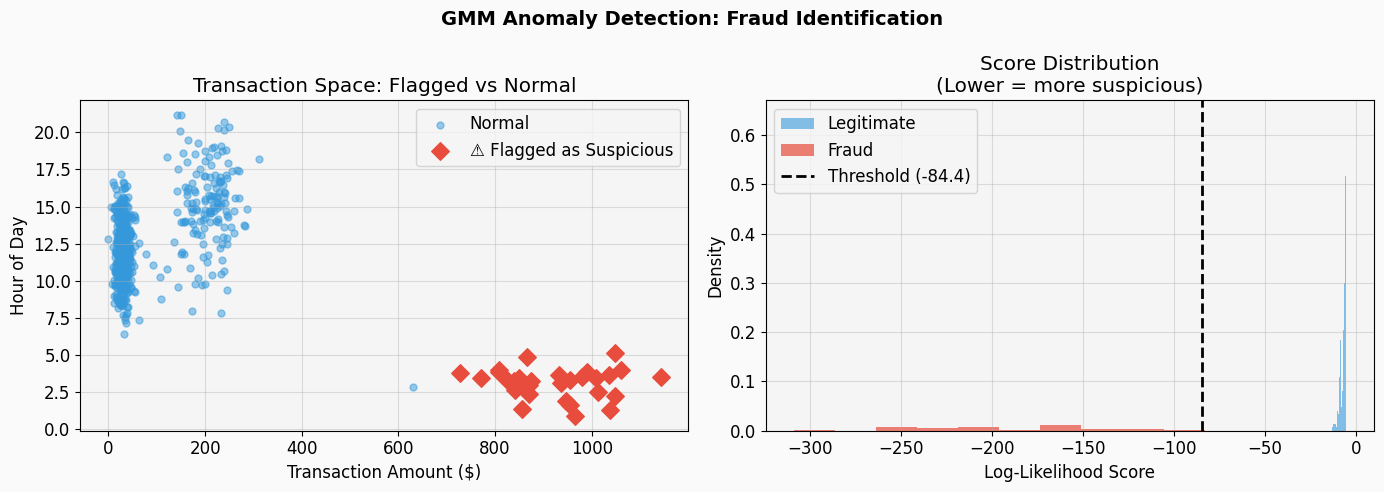


📊 Detection Results:
   Fraud transactions flagged: 29/30 (96.7%)
   Legitimate transactions falsely flagged: 0/550 (0.0%)


In [31]:
# Simulate bank transactions (mostly legitimate, a few fraudulent)
np.random.seed(55)

# Legitimate transactions: 2 clusters (small everyday, larger occasional)
legit_small  = np.column_stack([np.random.normal(30, 10, 400),
                                 np.random.normal(12, 2, 400)])   # (amount, hour)
legit_large  = np.column_stack([np.random.normal(200, 40, 150),
                                 np.random.normal(15, 3, 150)])
legit = np.vstack([legit_small, legit_large])

# Fraudulent transactions: unusual amounts at unusual hours
fraud = np.column_stack([np.random.normal(900, 100, 30),
                          np.random.normal(3, 1, 30)])   # 3am transactions

# Train GMM ONLY on legitimate data
gmm_fraud = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_fraud.fit(legit)

# Score ALL transactions (including fraud) — lower log-likelihood = more anomalous
all_transactions = np.vstack([legit, fraud])
log_likelihood = gmm_fraud.score_samples(all_transactions)

# Set a threshold: flag the bottom 5% as suspicious
threshold = np.percentile(log_likelihood, 5)
is_flagged = log_likelihood < threshold

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GMM Anomaly Detection: Fraud Identification', fontsize=14, fontweight='bold')

# Scatter: all transactions colored by flagged/not
n_legit = len(legit)
true_labels = np.array(['Legitimate']*n_legit + ['Fraud']*len(fraud))

axes[0].scatter(all_transactions[~is_flagged, 0], all_transactions[~is_flagged, 1],
                c='#3498DB', alpha=0.5, s=25, label='Normal')
axes[0].scatter(all_transactions[is_flagged, 0], all_transactions[is_flagged, 1],
                c='#E74C3C', s=80, marker='D', zorder=5, label='⚠️ Flagged as Suspicious')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Hour of Day')
axes[0].set_title('Transaction Space: Flagged vs Normal')
axes[0].legend()

# Log-likelihood distribution
axes[1].hist(log_likelihood[:n_legit], bins=30, color='#3498DB', alpha=0.6, label='Legitimate', density=True)
axes[1].hist(log_likelihood[n_legit:], bins=10, color='#E74C3C', alpha=0.7, label='Fraud', density=True)
axes[1].axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.1f})')
axes[1].set_xlabel('Log-Likelihood Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution\n(Lower = more suspicious)')
axes[1].legend()

plt.tight_layout()
plt.savefig('gmm_fraud_detection.png', dpi=120, bbox_inches='tight')
plt.show()

flagged_fraud = np.sum(is_flagged[n_legit:])
flagged_legit = np.sum(is_flagged[:n_legit])
print(f"\n📊 Detection Results:")
print(f"   Fraud transactions flagged: {flagged_fraud}/{len(fraud)} ({100*flagged_fraud/len(fraud):.1f}%)")
print(f"   Legitimate transactions falsely flagged: {flagged_legit}/{n_legit} ({100*flagged_legit/n_legit:.1f}%)")

---
## 🔨 TO-DO 2: GMM — Model Selection & Exploration

### Your Tasks:

**Task A:** Fit GMMs with `n_components` = 1, 2, 3, 4, 5 on the customer dataset from Part 1. For each, record its **BIC score** (`gmm.bic(X_scaled)`). Plot BIC vs. number of components — the *lowest* BIC wins.

**Task B:** Using the best GMM from Task A, print the **soft probability assignment** for 5 sample customers. Identify which customers are "on the boundary" between two segments.

**Task C:** Try different `covariance_type` values: `'full'`, `'tied'`, `'diag'`, `'spherical'`. Which gives the lowest BIC? What does each type assume about cluster shape?

> **Hint:** `GaussianMixture(n_components=3, covariance_type='full').fit(X_scaled)`

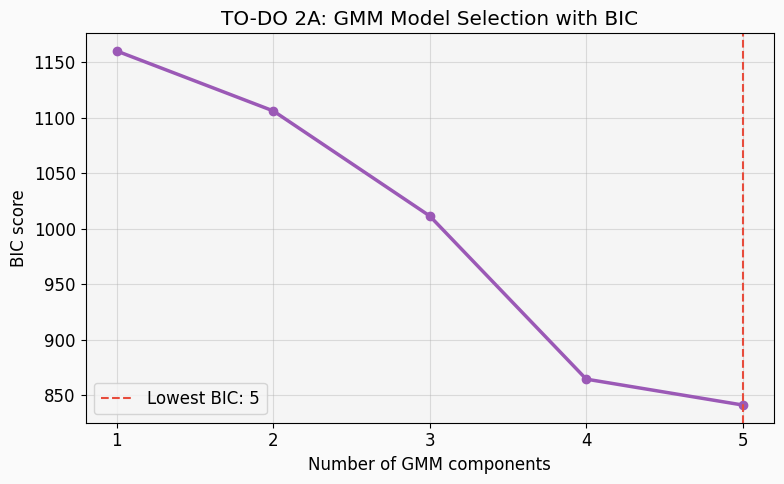

n_components=1: BIC=1159.94
n_components=2: BIC=1106.02
n_components=3: BIC=1011.41
n_components=4: BIC=864.52
n_components=5: BIC=841.21
Corrected result: lowest BIC selects 5 components.


In [32]:
# ===== TO-DO Task A: BIC model selection =====
# Error fixed: the original cell did not fit the models or compute BIC.

bic_scores = []
component_range = range(1, 6)
for n in component_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

best_components = list(component_range)[int(np.argmin(bic_scores))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(component_range), bic_scores, 'o-', color='#9B59B6', linewidth=2.5)
ax.axvline(best_components, color='#E74C3C', linestyle='--', label=f'Lowest BIC: {best_components}')
ax.set_xlabel('Number of GMM components')
ax.set_ylabel('BIC score')
ax.set_title('TO-DO 2A: GMM Model Selection with BIC')
ax.set_xticks(list(component_range))
ax.legend()
plt.tight_layout()
plt.savefig('todo2_gmm_bic.png', dpi=120, bbox_inches='tight')
plt.show()

for n, bic in zip(component_range, bic_scores):
    print(f'n_components={n}: BIC={bic:.2f}')
print(f'Corrected result: lowest BIC selects {best_components} components.')


In [33]:
# ===== TO-DO Task B: Soft assignments for 5 customers =====
# Error fixed: the original cell did not create best_gmm or compute probabilities.

best_gmm = GaussianMixture(n_components=best_components, covariance_type='full', random_state=42)
best_gmm.fit(X_scaled)
probs = best_gmm.predict_proba(X_scaled)

sample_indices = [0, 40, 80, 120, 160]
prob_df = pd.DataFrame(probs[sample_indices], index=[f'Customer {i}' for i in sample_indices])
prob_df.columns = [f'Component {i+1}' for i in range(best_components)]
print(prob_df.round(3))

max_probs = probs.max(axis=1)
boundary_customers = np.where(max_probs < 0.70)[0]
print(f'\nBoundary customers with max probability < 0.70: {boundary_customers[:10].tolist()}')
print(f'Total boundary customers: {len(boundary_customers)}')
print('Explanation: a boundary customer has no very dominant component probability, so GMM is uncertain about the segment.')


              Component 1  Component 2  Component 3  Component 4  Component 5
Customer 0            0.0          0.0          1.0          0.0          0.0
Customer 40           1.0          0.0          0.0          0.0          0.0
Customer 80           0.0          0.0          0.0          0.0          1.0
Customer 120          0.0          1.0          0.0          0.0          0.0
Customer 160          0.0          0.0          0.0          1.0          0.0

Boundary customers with max probability < 0.70: [31, 66, 73]
Total boundary customers: 3
Explanation: a boundary customer has no very dominant component probability, so GMM is uncertain about the segment.


In [34]:
# ===== TO-DO Task C: Compare covariance types =====
# Error fixed: covariance types were only listed in comments in the original notebook.

cov_types = ['full', 'tied', 'diag', 'spherical']
cov_results = []
for cov in cov_types:
    gmm = GaussianMixture(n_components=best_components, covariance_type=cov, random_state=42)
    gmm.fit(X_scaled)
    bic = gmm.bic(X_scaled)
    cov_results.append((cov, bic))
    print(f'{cov}: BIC = {bic:.2f}')

best_cov, best_cov_bic = min(cov_results, key=lambda item: item[1])
print(f'\nCorrected result: lowest BIC covariance type is {best_cov!r}.')
print('full = each cluster has its own ellipse; tied = all clusters share one covariance; diag = axis-aligned ellipses; spherical = circular clusters.')


full: BIC = 841.21
tied: BIC = 788.69
diag: BIC = 819.22
spherical: BIC = 819.27

Corrected result: lowest BIC covariance type is 'tied'.
full = each cluster has its own ellipse; tied = all clusters share one covariance; diag = axis-aligned ellipses; spherical = circular clusters.


## ❓ Reflection Questions — GMM

1. **What is BIC** and why do we prefer lower BIC? How is it different from just picking the highest likelihood?

2. **Why train the fraud detection GMM on legitimate data only?** What would happen if we included fraud transactions in training?

3. **In Task B**, what does it mean for a customer to have soft assignments of `[0.51, 0.49, 0.00]`? Is this a problem or useful information?

4. **Compare the threshold choice in fraud detection**: If we lower the threshold (flag the bottom 1% instead of 5%), what happens to fraud detection rate and false alarms? What is this tradeoff called?

5. **When would you choose GMM over K-Means?** Give two concrete scenarios.

### Answers ? GMM

1. BIC means Bayesian Information Criterion. It balances model fit with model complexity, so lower BIC is preferred. It differs from pure likelihood because it penalizes adding too many parameters.

2. The fraud detection GMM is trained only on legitimate data so it learns normal behaviour. If fraud is included in training, the model may treat fraudulent patterns as normal and miss them later.

3. A soft assignment like `[0.51, 0.49, 0.00]` means the point is almost equally likely to belong to two clusters. This is useful because it shows uncertainty instead of hiding it behind one hard label.

4. If the threshold is lowered from bottom 5% to bottom 1%, fewer transactions are flagged. False alarms decrease, but some fraud may be missed. This is the precision-recall or false-positive/false-negative tradeoff.

5. GMM is better than K-Means when clusters overlap and when clusters have elliptical shapes. Examples include customer segments with boundary customers and anomaly detection where probability/confidence matters.


---
# 📉 PART 3: Principal Component Analysis (PCA)

## The Curse of Dimensionality

Real datasets often have dozens or hundreds of features. Extra features can:
- Add **noise** that drowns out real patterns
- Make algorithms **slow** (data is large)
- Make **visualization impossible** (we can only see 2D/3D)

**PCA** finds the directions of *maximum variance* in your data and projects everything onto those directions.  
Result: fewer dimensions, but most information preserved.

```
Original data (784 dimensions)
         ↓  PCA
Compressed data (10 dimensions)  ← Most information kept!
```

## 🔬 Worked Example 6: PCA on the Digits Dataset

We'll use the famous MNIST-style **digits dataset** (8×8 = 64 dimensions of pixel intensity).

Dataset shape: (1797, 64)
Each image is (8, 8) pixels


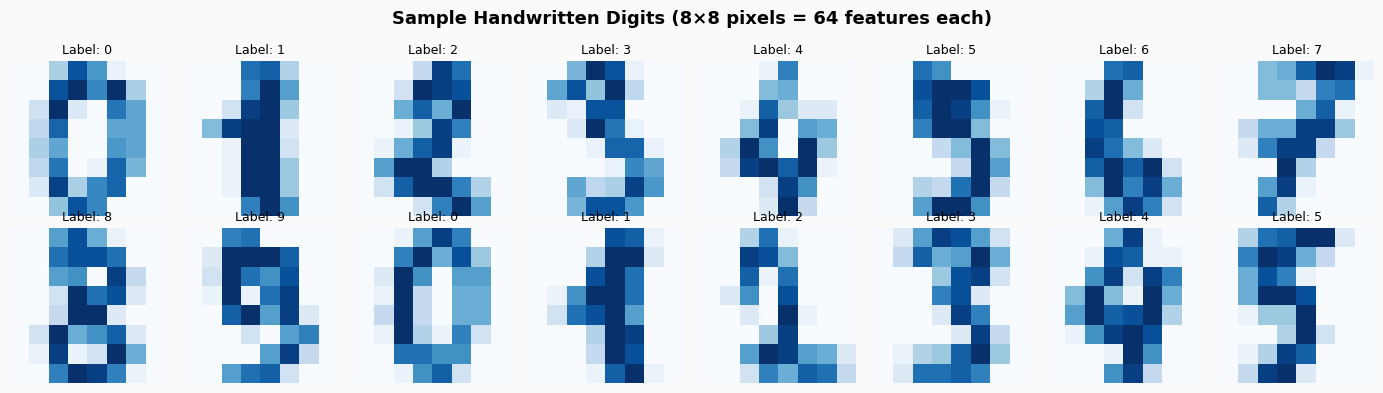

In [35]:
# Load digits dataset: 1797 images, each 8x8 = 64 features
digits = load_digits()
X_digits = digits.data         # shape: (1797, 64)
y_digits = digits.target       # labels 0-9

print(f"Dataset shape: {X_digits.shape}")
print(f"Each image is {digits.images[0].shape} pixels")

# Show some sample digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Sample Handwritten Digits (8×8 pixels = 64 features each)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='Blues')
    ax.set_title(f'Label: {y_digits[i]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('digits_samples.png', dpi=120, bbox_inches='tight')
plt.show()

   90% variance explained by 31 components (out of 64)
   95% variance explained by 40 components (out of 64)
   99% variance explained by 54 components (out of 64)


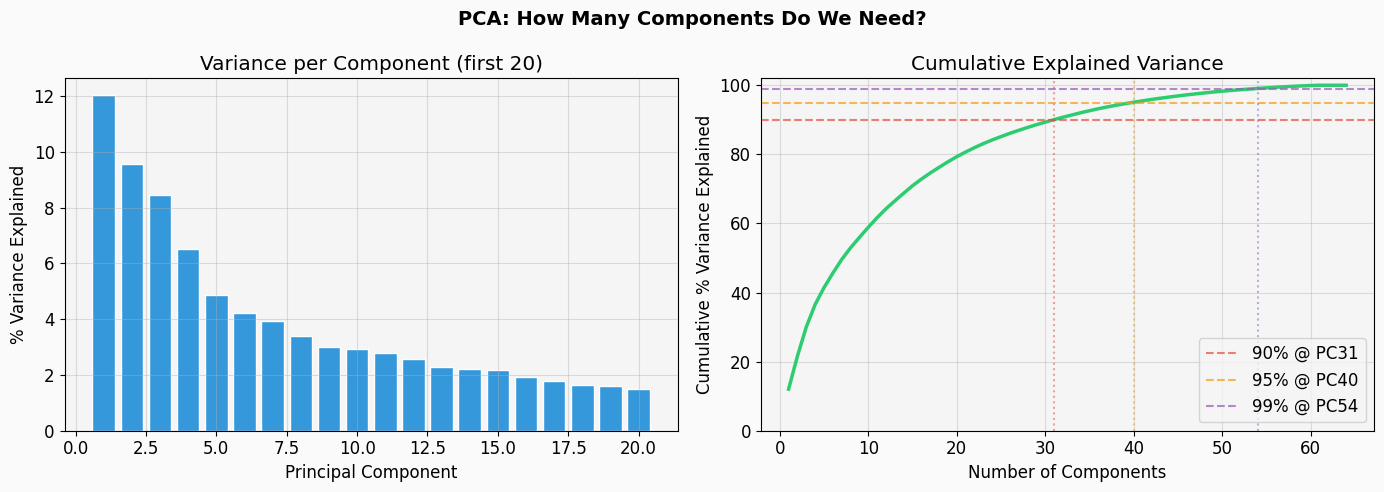

In [36]:
# Apply PCA and examine explained variance
scaler_pca = StandardScaler()
X_digits_scaled = scaler_pca.fit_transform(X_digits)

pca_full = PCA(random_state=42)
pca_full.fit(X_digits_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Find how many PCs explain 90%, 95%, 99%
for target in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative >= target) + 1
    print(f"   {int(target*100)}% variance explained by {n_components} components (out of 64)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA: How Many Components Do We Need?', fontsize=14, fontweight='bold')

# Individual explained variance
axes[0].bar(range(1, 21), explained[:20] * 100, color='#3498DB', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('% Variance Explained')
axes[0].set_title('Variance per Component (first 20)')

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, color='#2ECC71', linewidth=2.5)
for target, color in [(90, '#E74C3C'), (95, '#F39C12'), (99, '#9B59B6')]:
    n = np.argmax(cumulative >= target/100) + 1
    axes[1].axhline(y=target, color=color, linestyle='--', alpha=0.7, label=f'{target}% @ PC{n}')
    axes[1].axvline(x=n, color=color, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative % Variance Explained')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()

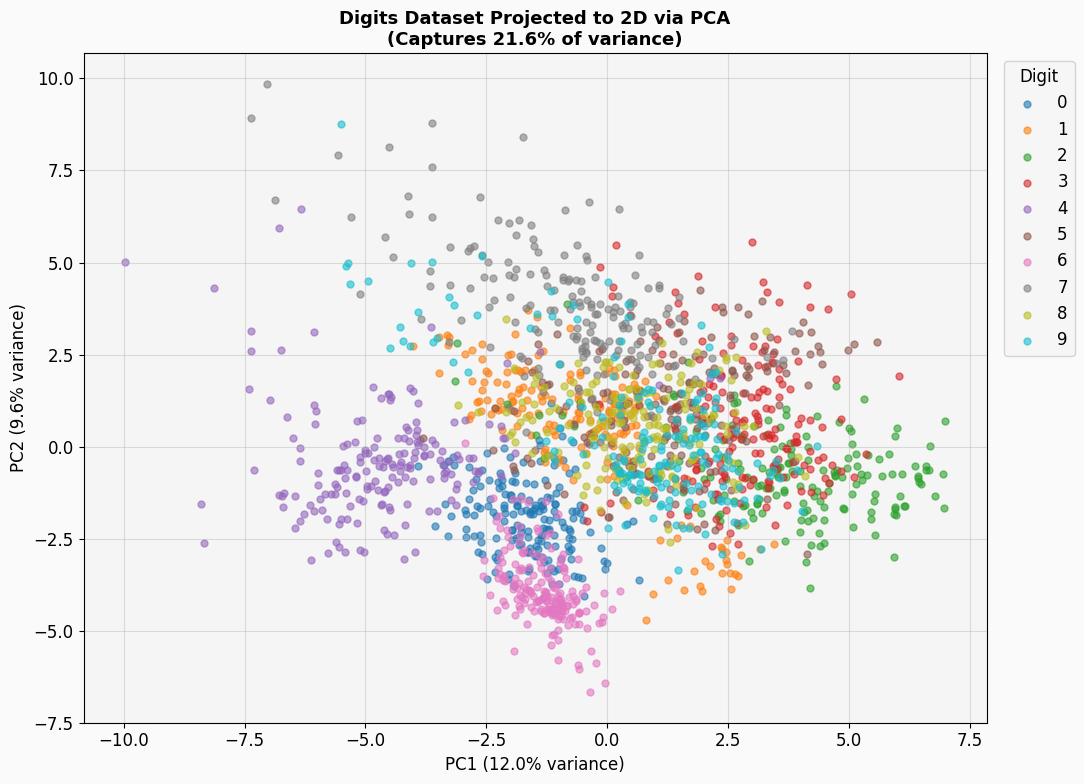

Notice how similar digits cluster together even in just 2 dimensions!


In [37]:
# Project digits to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_digits_scaled)

fig, ax = plt.subplots(figsize=(11, 8))
scatter_colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y_digits == digit
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[scatter_colors[digit]], alpha=0.6, s=25, label=str(digit))

ax.set_title(f'Digits Dataset Projected to 2D via PCA\n'
             f'(Captures {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Digit', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.savefig('pca_2d_digits.png', dpi=120, bbox_inches='tight')
plt.show()
print("Notice how similar digits cluster together even in just 2 dimensions!")

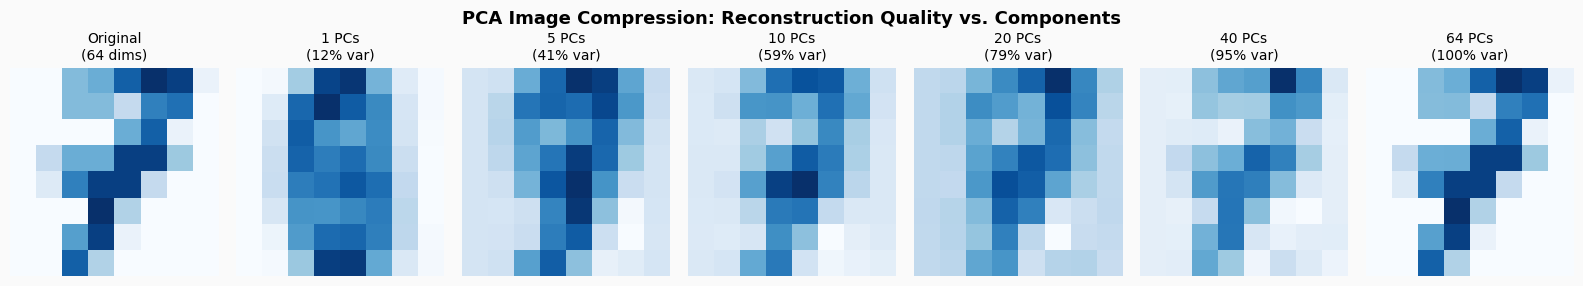

In [38]:
# Image reconstruction: how many components until quality is good enough?
n_components_list = [1, 5, 10, 20, 40, 64]
sample_idx = 7  # choose a sample digit to reconstruct

fig, axes = plt.subplots(1, len(n_components_list) + 1, figsize=(16, 3))
fig.suptitle('PCA Image Compression: Reconstruction Quality vs. Components',
             fontsize=13, fontweight='bold')

# Original
axes[0].imshow(digits.images[sample_idx], cmap='Blues')
axes[0].set_title('Original\n(64 dims)', fontsize=10)
axes[0].axis('off')

for ax, n in zip(axes[1:], n_components_list):
    pca_n = PCA(n_components=n, random_state=42)
    X_reduced = pca_n.fit_transform(X_digits_scaled)
    X_reconstructed = pca_n.inverse_transform(X_reduced)
    X_reconstructed = scaler_pca.inverse_transform(X_reconstructed)
    
    img_reconstructed = X_reconstructed[sample_idx].reshape(8, 8)
    var_kept = pca_n.explained_variance_ratio_.sum() * 100
    
    ax.imshow(img_reconstructed, cmap='Blues')
    ax.set_title(f'{n} PCs\n({var_kept:.0f}% var)', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('pca_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🔨 TO-DO 3: PCA — Exploration & Pipeline

### Your Tasks:

**Task A:** Apply PCA to reduce the digits dataset to **2 components**, then run **K-Means** on the 2D data. Compare the clustering accuracy to clustering on the original 64D data. Which is better?

**Task B:** Try keeping 10 components instead of 2 for the K-Means step. Does accuracy improve?

**Task C:** Use `pca.components_` to visualize the first 8 principal components as 8×8 images. What patterns do they capture?

> **Hint for Task A:** Use `from sklearn.metrics import adjusted_rand_score` to compare cluster labels to true digit labels.

In [39]:
# ===== TO-DO Task A: PCA + K-Means pipeline =====
from sklearn.metrics import adjusted_rand_score
# Error fixed: the original cell stopped at NotImplementedError.

# Step 1: Reduce to 2D with PCA.
pca_2 = PCA(n_components=2, random_state=42)
X_2d_todo = pca_2.fit_transform(X_digits_scaled)

# Step 2: K-Means on 2D data.
km_2d = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_2d = km_2d.fit_predict(X_2d_todo)

# Step 3: K-Means on original scaled 64D data.
km_64d = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_64d = km_64d.fit_predict(X_digits_scaled)

# Step 4: Compare ARI scores.
ari_2d = adjusted_rand_score(y_digits, labels_2d)
ari_64d = adjusted_rand_score(y_digits, labels_64d)
print(f'ARI (2D PCA): {ari_2d:.3f}')
print(f'ARI (64D original): {ari_64d:.3f}')
print('Explanation: ARI closer to 1 is better. The original 64D data usually keeps more information than only 2 PCs.')


ARI (2D PCA): 0.326
ARI (64D original): 0.534
Explanation: ARI closer to 1 is better. The original 64D data usually keeps more information than only 2 PCs.


In [40]:
# ===== TO-DO Task B: Try 10 components =====
# Error fixed: this comparison was missing in the original notebook.

pca_10 = PCA(n_components=10, random_state=42)
X_10d_todo = pca_10.fit_transform(X_digits_scaled)

km_10d = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_10d = km_10d.fit_predict(X_10d_todo)
ari_10d = adjusted_rand_score(y_digits, labels_10d)

print(f'ARI (2D PCA): {ari_2d:.3f}')
print(f'ARI (10D PCA): {ari_10d:.3f}')
print(f'ARI (64D original): {ari_64d:.3f}')
print(f'10 PCs retain {pca_10.explained_variance_ratio_.sum()*100:.1f}% of variance.')
print('Explanation: 10 components usually improve over 2 components because they preserve more digit structure while still reducing noise/dimensionality.')


ARI (2D PCA): 0.326
ARI (10D PCA): 0.483
ARI (64D original): 0.534
10 PCs retain 58.9% of variance.
Explanation: 10 components usually improve over 2 components because they preserve more digit structure while still reducing noise/dimensionality.


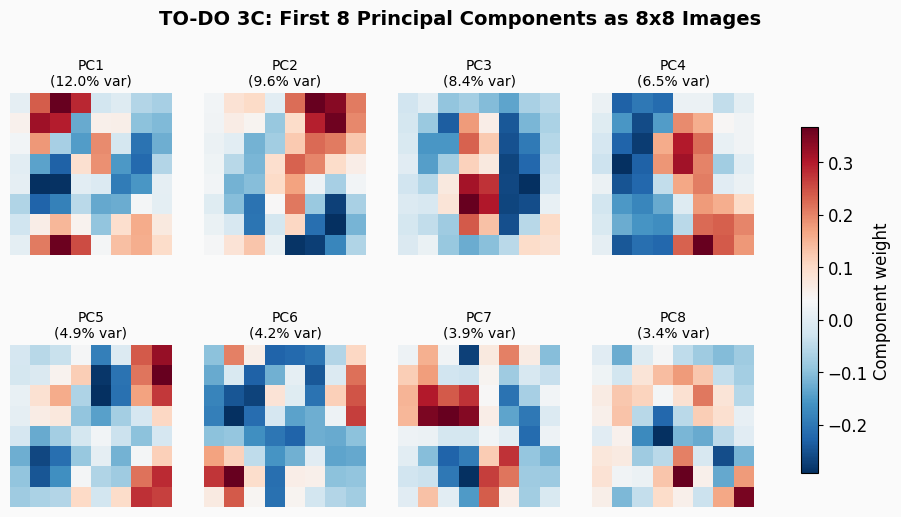

Explanation: bright and dark regions show pixels that vary together. Early PCs capture broad stroke patterns; later PCs capture finer details.


In [41]:
# ===== TO-DO Task C: Visualize principal components =====
# Error fixed: the original cell only contained commented hints.

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('TO-DO 3C: First 8 Principal Components as 8x8 Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    component = pca_full.components_[i].reshape(8, 8)
    im = ax.imshow(component, cmap='RdBu_r')
    ax.set_title(f'PC{i+1}\n({pca_full.explained_variance_ratio_[i]*100:.1f}% var)', fontsize=10)
    ax.axis('off')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, label='Component weight')
plt.savefig('todo3_principal_components.png', dpi=120, bbox_inches='tight')
plt.show()

print('Explanation: bright and dark regions show pixels that vary together. Early PCs capture broad stroke patterns; later PCs capture finer details.')


## ❓ Reflection Questions — PCA

1. **Why do we scale (StandardScaler) before PCA?** What happens if features have very different ranges?

2. **In the reconstruction experiment**, how many components are needed before the digit is clearly recognizable? What does this tell you about redundancy in pixel data?

3. **From Task A/B**, did adding more PCA components (2 → 10) improve K-Means clustering? Why might too few dimensions hurt? Why might the original 64D also sometimes perform worse than the right number of PCs?

4. **What do the principal component images (Task C) represent visually?** What kind of patterns do early PCs capture vs. later PCs?

5. **PCA is a linear method**. What does this mean, and what kind of data structure might PCA fail to capture? (Bonus: what non-linear alternative exists?)

### Answers ? PCA

1. We scale before PCA because PCA is variance-based. Features with larger numeric ranges would dominate the principal components even if they are not more important.

2. In the reconstruction experiment, the digit usually becomes clearly recognizable around 10 to 20 components. This shows that pixel data contains redundancy and can be compressed.

3. Moving from 2 to 10 PCA components improves clustering because 2 components discard too much useful digit information. The original 64D data can sometimes be worse than a good PCA representation because high-dimensional noise can make distances less meaningful.

4. Principal component images show directions of variation in pixel space. Early PCs capture broad stroke locations and contrasts; later PCs capture smaller details and noise-like patterns.

5. PCA is linear, meaning it only finds straight-line projections of the data. It can fail on curved/nonlinear structures such as moons or spirals. A nonlinear alternative is t-SNE, UMAP, or kernel PCA.


---
# 🏆 BONUS CHALLENGE: Full Unsupervised Learning Pipeline

Combine everything you've learned into one pipeline!

### Task:
1. Load the digits dataset
2. Scale it
3. Reduce to **20 components** with PCA
4. Fit a **GMM** with 10 components on the reduced data
5. Compare GMM's BIC to K-Means inertia for K=10
6. Visualize the GMM soft-assignment uncertainty (which digits are most ambiguous?)
7. **Extra challenge:** Use the 2D PCA projection to visualize which digits the GMM is most uncertain about

PCA variance retained with 20 components: 79.3%
GMM BIC (10 components): 78541.40
K-Means inertia (K=10): 47540.16
GMM ARI: 0.449
K-Means ARI: 0.397


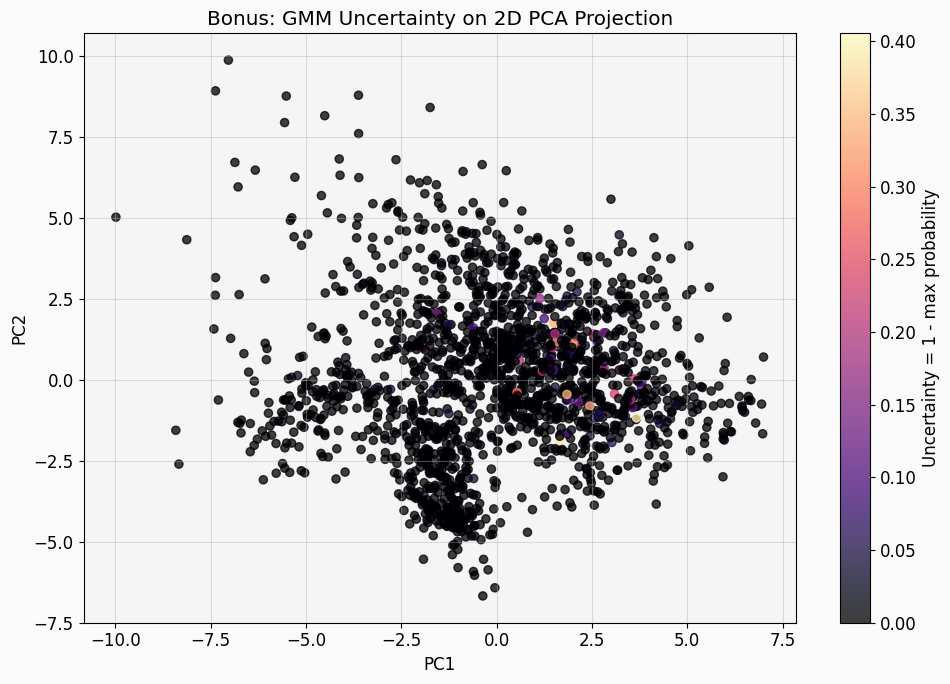

Most uncertain digit indices: [122, 463, 446, 288, 1141, 1758, 1513, 1340, 1632, 1489]
Their true labels: [8, 2, 3, 5, 8, 3, 3, 8, 3, 5]
Explanation: high uncertainty means the GMM sees the digit as lying near the boundary between mixture components.


In [42]:
# ===== BONUS CHALLENGE =====
# Error fixed: the original bonus cell was empty and raised NotImplementedError.

# 1-3. Load, scale, and reduce digits to 20 PCA components.
digits_bonus = load_digits()
X_bonus = digits_bonus.data
y_bonus = digits_bonus.target
X_bonus_scaled = StandardScaler().fit_transform(X_bonus)

pca_20 = PCA(n_components=20, random_state=42)
X_bonus_20 = pca_20.fit_transform(X_bonus_scaled)

# 4. Fit a GMM with 10 components on the reduced data.
gmm_digits = GaussianMixture(n_components=10, covariance_type='full', random_state=42)
gmm_labels = gmm_digits.fit_predict(X_bonus_20)
gmm_probs = gmm_digits.predict_proba(X_bonus_20)

# 5. Compare GMM BIC to K-Means inertia for K=10.
km_digits = KMeans(n_clusters=10, random_state=42, n_init=10)
km_digits_labels = km_digits.fit_predict(X_bonus_20)

gmm_bic = gmm_digits.bic(X_bonus_20)
km_inertia = km_digits.inertia_
gmm_ari = adjusted_rand_score(y_bonus, gmm_labels)
km_ari = adjusted_rand_score(y_bonus, km_digits_labels)

print(f'PCA variance retained with 20 components: {pca_20.explained_variance_ratio_.sum()*100:.1f}%')
print(f'GMM BIC (10 components): {gmm_bic:.2f}')
print(f'K-Means inertia (K=10): {km_inertia:.2f}')
print(f'GMM ARI: {gmm_ari:.3f}')
print(f'K-Means ARI: {km_ari:.3f}')

# 6-7. Visualize GMM soft-assignment uncertainty on the 2D PCA projection.
pca_bonus_2d = PCA(n_components=2, random_state=42)
X_bonus_2d = pca_bonus_2d.fit_transform(X_bonus_scaled)
uncertainty = 1 - gmm_probs.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_bonus_2d[:, 0], X_bonus_2d[:, 1], c=uncertainty, cmap='magma', s=35, alpha=0.75)
ax.set_title('Bonus: GMM Uncertainty on 2D PCA Projection')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Uncertainty = 1 - max probability')
plt.tight_layout()
plt.savefig('bonus_gmm_uncertainty.png', dpi=120, bbox_inches='tight')
plt.show()

most_uncertain = np.argsort(uncertainty)[-10:][::-1]
print('Most uncertain digit indices:', most_uncertain.tolist())
print('Their true labels:', y_bonus[most_uncertain].tolist())
print('Explanation: high uncertainty means the GMM sees the digit as lying near the boundary between mixture components.')


---
# 📚 Summary: What You've Learned

| Algorithm | Type | Key Idea | When to Use |
|---|---|---|---|
| **K-Means** | Hard clustering | Assign each point to nearest centroid | Distinct, spherical clusters |
| **GMM** | Soft clustering | Model data as mixture of Gaussians | Overlapping clusters, need probabilities |
| **PCA** | Dimensionality reduction | Keep directions of max variance | Too many features, visualization, noise removal |

## Key Takeaways
- **Always scale your data** before K-Means, GMM, or PCA
- **Use the Elbow Method / BIC** to choose the number of clusters
- **PCA + Clustering** is a powerful combination for high-dimensional data
- **Soft assignments (GMM)** give you uncertainty information that hard assignments (K-Means) hide
- **Anomaly detection** with GMM works by flagging points with low log-likelihood

---
*Notebook complete! Make sure you've answered all the Reflection Questions and completed all To-Do tasks.*